In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('PGA_Data.csv')
df = df[["player", "season", "sg_ott", "sg_app", "sg_arg", "sg_putt", "sg_total"]]
display(df.head(5))

,player,season,sg_ott,sg_app,sg_arg,sg_putt,sg_total
0,Abraham Ancer,2022,0.86,-0.08,-0.13,0.20,0.85
1,Adam Hadwin,2022,0.18,0.31,0.75,0.36,1.60
2,Anirban Lahiri,2022,0.37,-1.09,0.74,-0.56,-0.54
3,Adam Long,2022,0.80,-0.02,-1.86,-1.46,-2.54
4,Alexander Noren,2022,0.19,-1.39,-0.36,0.53,-1.04


In [10]:
def normalize(series):
    # scale to 0-1 probability
    return (series - series.min()) / (series.max() - series.min())

df["p_tee_fairway"] = normalize(df["sg_ott"])
df["p_fairway_green"] = normalize(df["sg_app"])
df["p_rough_green"] = normalize(df["sg_app"] * 0.6)   
df["p_bunker_green"] = normalize(df["sg_arg"])
df["p_green_hole"] = normalize(df["sg_putt"])

In [11]:
p_tee_fairway   = df["p_tee_fairway"].mean()
p_fairway_green = df["p_fairway_green"].mean()
p_rough_green   = df["p_rough_green"].mean()
p_bunker_green  = df["p_bunker_green"].mean()
p_green_hole    = df["p_green_hole"].mean()

In [12]:
states = ["Tee", "Fairway", "Rough", "Bunker", "Green", "Hole"]
transition_matrix = pd.DataFrame(0.0, index=states, columns=states)

# Tee
transition_matrix.loc["Tee", "Fairway"] = p_tee_fairway
transition_matrix.loc["Tee", "Rough"]   = (1 - p_tee_fairway) * 0.7
transition_matrix.loc["Tee", "Bunker"]  = (1 - p_tee_fairway) * 0.3

# Fairway
# Fairway transitions
transition_matrix.loc["Fairway", "Green"]   = p_fairway_green
transition_matrix.loc["Fairway", "Rough"]   = (1 - p_fairway_green) * 0.5
transition_matrix.loc["Fairway", "Bunker"]  = (1 - p_fairway_green) * 0.3
transition_matrix.loc["Fairway", "Fairway"] = (1 - p_fairway_green) * 0.2 


# Rough
transition_matrix.loc["Rough", "Green"]  = p_rough_green
transition_matrix.loc["Rough", "Rough"]  = (1 - p_rough_green) * 0.5
transition_matrix.loc["Rough", "Bunker"] = (1 - p_rough_green) * 0.5

# Bunker
transition_matrix.loc["Bunker", "Green"] = p_bunker_green
transition_matrix.loc["Bunker", "Rough"] = 1 - p_bunker_green


# Green
transition_matrix.loc["Green", "Hole"]  = p_green_hole
transition_matrix.loc["Green", "Green"] = 1 - p_green_hole

# Hole is absorbing
transition_matrix.loc["Hole", "Hole"] = 1.0

print("Transition Matrix:\n")
print(transition_matrix.round(2))
print(type(transition_matrix))

Transition Matrix:

         Tee  Fairway  Rough  Bunker  Green  Hole
Tee      0.0     0.73   0.19    0.08   0.00  0.00
Fairway  0.0     0.07   0.17    0.10   0.66  0.00
Rough    0.0     0.00   0.17    0.17   0.66  0.00
Bunker   0.0     0.00   0.33    0.00   0.67  0.00
Green    0.0     0.00   0.00    0.00   0.44  0.56
Hole     0.0     0.00   0.00    0.00   0.00  1.00
<class 'pandas.core.frame.DataFrame'>


In [13]:
def simulate_hole(P, start_state=0):
    """
    Simulate one full hole using transition probabilities.
    P: transition probability matrix (numpy array)
    start_state: index of starting state (usually 0 = 'Tee')
    """
    current_state = start_state
    strokes = 0

    while current_state != len(P) - 1:  # Continue until 'Hole'
        strokes += 1
        current_state = np.random.choice(range(len(P)), p=P[current_state])

    return strokes


In [14]:
n_rounds = 1000  # Scale to many random samples
results = [simulate_hole(P) for _ in range(n_rounds)]

mean_strokes = np.mean(results)
variance_strokes = np.var(results)

print(f"Mean strokes per hole: {mean_strokes:.2f}")
print(f"Variance: {variance_strokes:.2f}")


NameError: name 'P' is not defined

In [15]:
import matplotlib.pyplot as plt

plt.hist(results, bins=15, alpha=0.7, density=True, color='skyblue', edgecolor='black')
plt.title("Monte Carlo Simulation Across Entire Hole")
plt.xlabel("Total Strokes to Complete Hole")
plt.ylabel("Probability Density")
plt.show()


NameError: name 'results' is not defined

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.17288207..1.1350912].


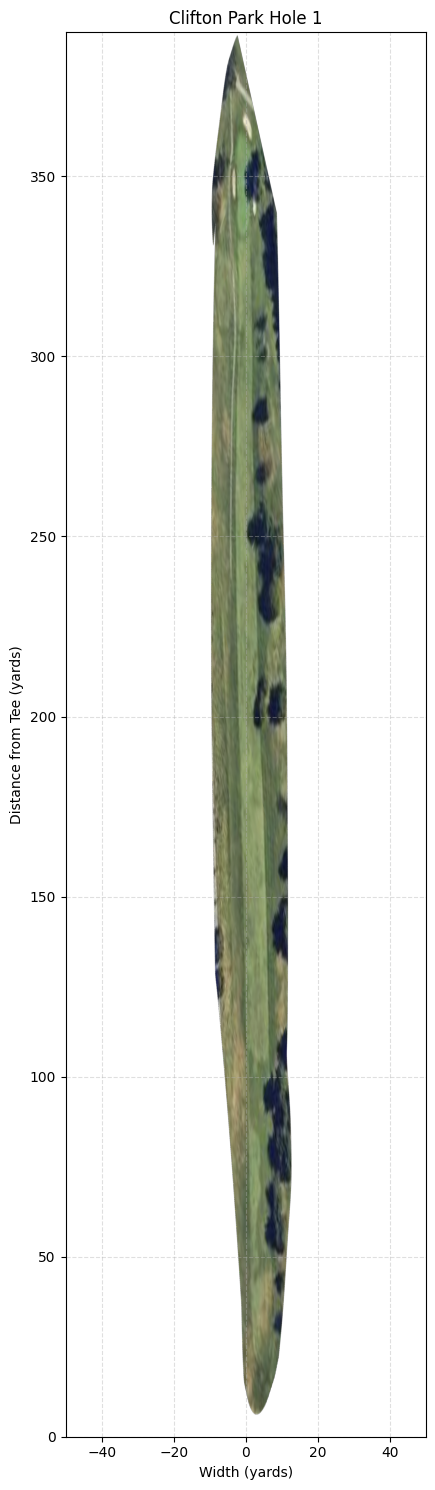

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.ndimage import rotate

# Load the image
img = mpimg.imread("hole1.png")

# Rotate the image counterclockwise by e.g. 15–20 degrees
rotated = rotate(img, angle=40, reshape=True)   # tweak angle until the hole is vertical
mask = np.any(rotated < 0.99, axis=2)
coords = np.argwhere(mask)
y0, x0 = coords.min(axis=0)
y1, x1 = coords.max(axis=0)
cropped = rotated[y0:y1, x0:x1]
# Display it yard-scaled
fig, ax = plt.subplots(figsize=(8, 15))
ax.imshow(rotated, extent=[-50, 50, 0, 390], origin='upper')

ax.set_title("Clifton Park Hole 1")
ax.set_xlabel("Width (yards)")
ax.set_ylabel("Distance from Tee (yards)")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



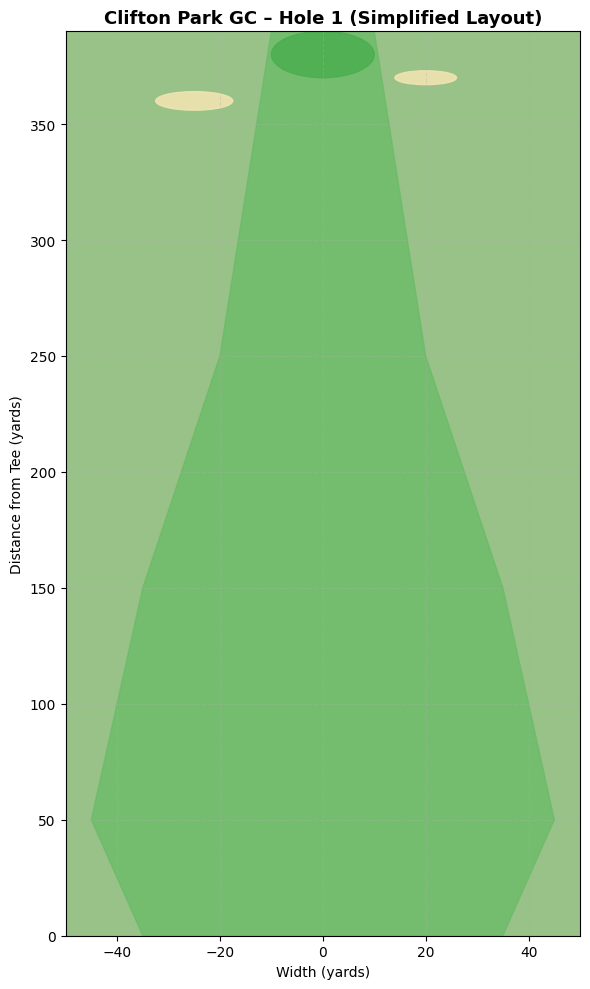

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Polygon, Circle

fig, ax = plt.subplots(figsize=(6, 10))

# Draw fairway as a green polygon
fairway_coords = [
    (-35, 0), (-45, 50), (-35, 150), (-20, 250), (-10, 390),
    (10, 390), (20, 250), (35, 150), (45, 50), (35, 0)
]
fairway = Polygon(fairway_coords, closed=True, color='#66bb66', alpha=0.7)
ax.add_patch(fairway)

# Draw green as a circle
green = Circle((0, 380), 10, color='#4CAF50', alpha=0.9)
ax.add_patch(green)

# Draw bunkers
bunker1 = Ellipse((-25, 360), 15, 8, color='#f0e4b2', alpha=0.9)
bunker2 = Ellipse((20, 370), 12, 6, color='#f0e4b2', alpha=0.9)
ax.add_patch(bunker1)
ax.add_patch(bunker2)

# Draw rough area background
ax.set_facecolor('#98c287')

# Style & axes
ax.set_xlim(-50, 50)
ax.set_ylim(0, 390)
ax.set_title("Clifton Park GC – Hole 1 (Simplified Layout)", fontsize=13, weight='bold')
ax.set_xlabel("Width (yards)")
ax.set_ylabel("Distance from Tee (yards)")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


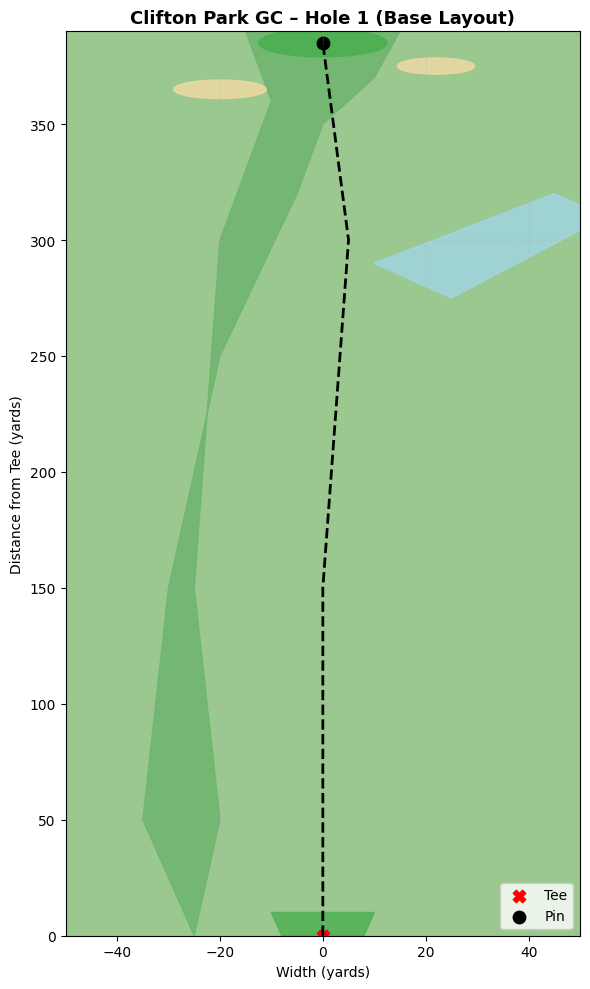

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Ellipse, Circle

# Yard dimensions
hole_length = 390
hole_width = 100

fig, ax = plt.subplots(figsize=(6, 10))

# --- BACKGROUND (rough) ---
ax.set_facecolor('#9bc88f')  # muted green background

# --- FAIRWAY ---
fairway_coords = [
    (-25, 0), (-35, 50), (-30, 150), (-20, 250), (-5, 320),
    (0, 350), (10, 370), (15, 390), (-15, 390), (-10, 360),
    (-20, 300), (-25, 150), (-20, 50)
]
ax.add_patch(Polygon(fairway_coords, closed=True, color='#6DB56D', alpha=0.85))

# --- GREEN ---
green = Ellipse((0, 385), width=25, height=12, color='#4CAF50', alpha=0.9)
ax.add_patch(green)

# --- BUNKERS ---
ax.add_patch(Ellipse((-20, 365), 18, 8, color='#EBD8A3', alpha=0.9))
ax.add_patch(Ellipse((22, 375), 15, 7, color='#EBD8A3', alpha=0.9))

# --- WATER HAZARD ---
water = Polygon([(10, 290), (45, 320), (55, 310), (25, 275)],
                color='#A3D9FF', alpha=0.6)
ax.add_patch(water)

# --- TEE BOX AREA ---
tee = Polygon([(-8, 0), (8, 0), (10, 10), (-10, 10)], color='#4CAF50', alpha=0.8)
ax.add_patch(tee)

# --- PATH / SHOT LINE (placeholder) ---
ax.plot([0, 0, 5, 0], [0, 150, 300, 385], 'k--', linewidth=2)
ax.scatter([0], [0], c='red', s=80, marker='X', label='Tee')
ax.scatter([0], [385], c='black', s=80, marker='o', label='Pin')

# --- STYLING ---
ax.set_xlim(-hole_width/2, hole_width/2)
ax.set_ylim(0, hole_length)
ax.set_title("Clifton Park GC – Hole 1 (Base Layout)", fontsize=13, weight='bold')
ax.set_xlabel("Width (yards)")
ax.set_ylabel("Distance from Tee (yards)")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()
